# Exploratory Data Analysis

This notebook explores the master weekly dataset assembled in `data_cleaning.ipynb`. It covers time-series visualization of market volatility and health signals, correlation analysis (full period, pre-COVID, flu-season, and three-period breakdowns), statistical assumption tests (normality, multicollinearity, autocorrelation), lag analysis to test whether health signals lead market volatility, rolling correlation to detect regime changes, and volatility spike identification.

## Inspection & Validation

Confirm the master dataset loaded correctly and all 19 expected columns are present before beginning analysis.

In [3]:
import pandas as pd
temp = pd.read_csv('../data/processed/master_weekly.csv', index_col=0, parse_dates=True)
print(temp.columns.tolist())

['KIE', 'PJP', 'XBI', 'XLV', 'KIE_vol', 'PJP_vol', 'XBI_vol', 'XLV_vol', 'cpi', 'unemployment', 'interest_rate', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath', 'wili', 'ili', 'num_ili', 'num_patients', 'nchs_deaths']


All 19 expected columns are present: 4 ETF closing prices, 4 volatility measures, 3 FRED macro indicators, 3 Google Trends signals, 4 FluView ILI metrics, and NCHS annual deaths — confirming the cleaning notebook produced the correct output.

In [4]:
master_df = pd.read_csv('../data/processed/master_weekly.csv', index_col=0, parse_dates=True)
print(master_df.shape)
print(master_df.head())

(730, 19)
                 KIE        PJP        XBI        XLV   KIE_vol   PJP_vol  \
2010-01-10  9.090796  15.240718  17.882545  24.113842  0.008362  0.003628   
2010-01-17  9.083311  15.451389  17.709146  24.447704  0.009673  0.010266   
2010-01-24  8.753912  15.070560  17.683453  24.022779  0.018905  0.019470   
2010-01-31  8.801326  15.086777  17.750891  23.734453  0.011472  0.007059   
2010-02-07  8.689034  14.859903  17.635288  23.393009  0.022650  0.017009   

             XBI_vol   XLV_vol      cpi  unemployment  interest_rate  \
2010-01-10  0.005640  0.008323  217.488           9.8           0.11   
2010-01-17  0.013155  0.009322  217.488           9.8           0.11   
2010-01-24  0.016492  0.019807  217.488           9.8           0.11   
2010-01-31  0.010714  0.005937  217.488           9.8           0.11   
2010-02-07  0.027530  0.017616  217.281           9.8           0.13   

            trends_flu_symptoms  trends_fever  trends_shortness_of_breath  \
2010-01-10       

730 weekly observations from 2010-01-10 to 2023-12-31 with no unexpected gaps, matching the yfinance coverage confirmed in cleaning.

## Time Series Visualization

Plots each key variable over the full 14-year study window. The COVID period (2020-2021) is shaded red on each chart as a reference for the most significant health-market event in the dataset.

### Target: XLV Weekly Volatility

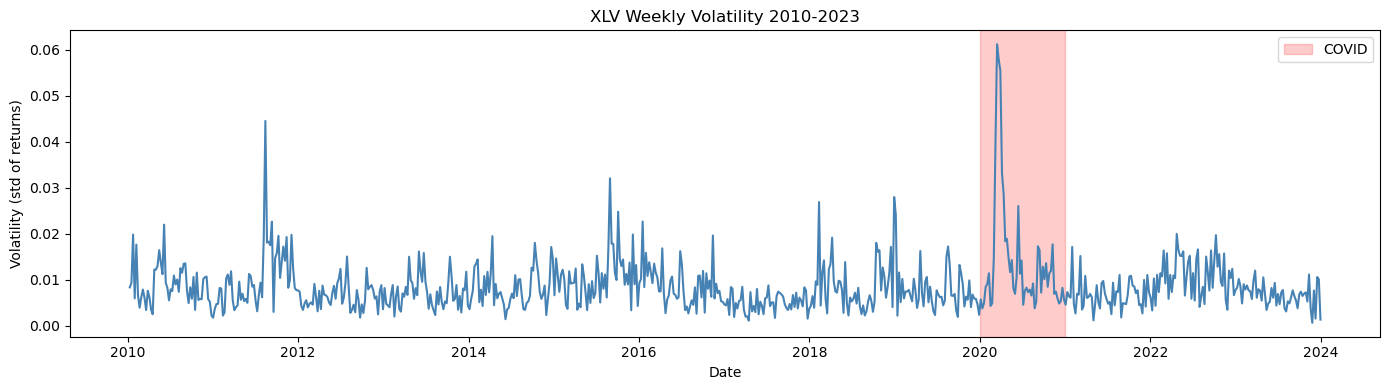

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(master_df.index, master_df['XLV_vol'], color='steelblue')
plt.title('XLV Weekly Volatility 2010-2023')
plt.xlabel('Date')
plt.ylabel('Volatility (std of returns)')
plt.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
plt.legend()
plt.tight_layout()
plt.show()

What it shows: A single line tracking how much XLV (the broad healthcare ETF) moved week to week over 14 years. Flat and low most of the time with one massive spike.
Interpretation: The market was calm for a decade, then COVID hit in early 2020 and volatility exploded to levels never seen before in this dataset. It calmed down by mid-2020 but stayed elevated through 2021.
Relevance: This is your target variable. Everything else in the project gets measured against this line. It proves the phenomenon you're studying is real and dramatic â€” markets do react to health events, the question is whether you can see it coming.

### Sector Comparison: All ETF Volatilities

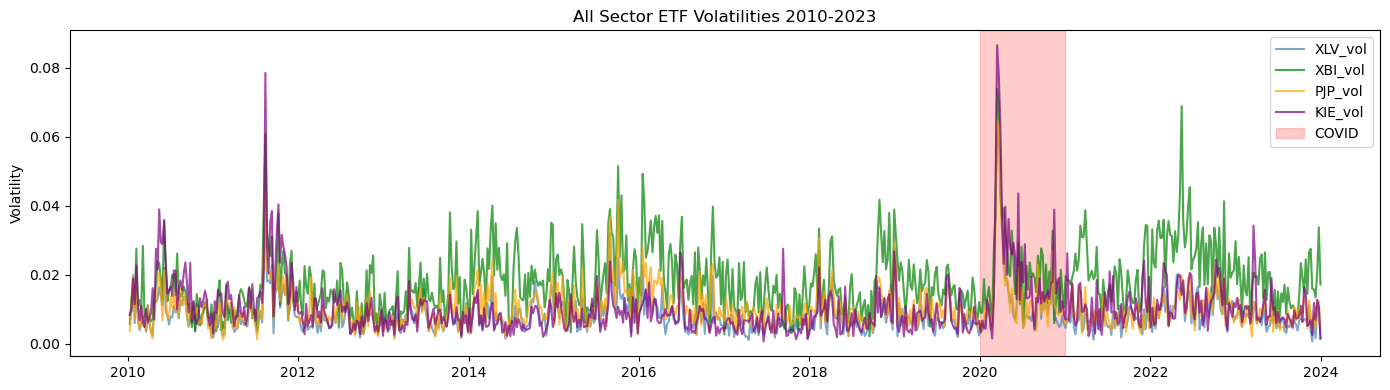

In [6]:
plt.figure(figsize=(14, 4))
for col, color in zip(['XLV_vol', 'XBI_vol', 'PJP_vol', 'KIE_vol'], ['steelblue', 'green', 'orange', 'purple']):
    plt.plot(master_df.index, master_df[col], label=col, color=color, alpha=0.7)
plt.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
plt.title('All Sector ETF Volatilities 2010-2023')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.savefig('plot2_all_vol.png', dpi=150)
plt.show()

What it shows: XLV, XBI, PJP, and KIE volatility on the same chart.
Interpretation: All four sectors spike together during COVID â€” they're correlated during extreme events. But in normal times they behave differently. XBI (biotech) is noisier throughout the full period, which makes sense since biotech is more speculative. KIE (insurance) is the calmest.
Relevance: Shows that the health-market relationship isn't sector-specific â€” it hits all four simultaneously during a real crisis. But the magnitude differs by sector.

### Health Signal: Weighted ILI

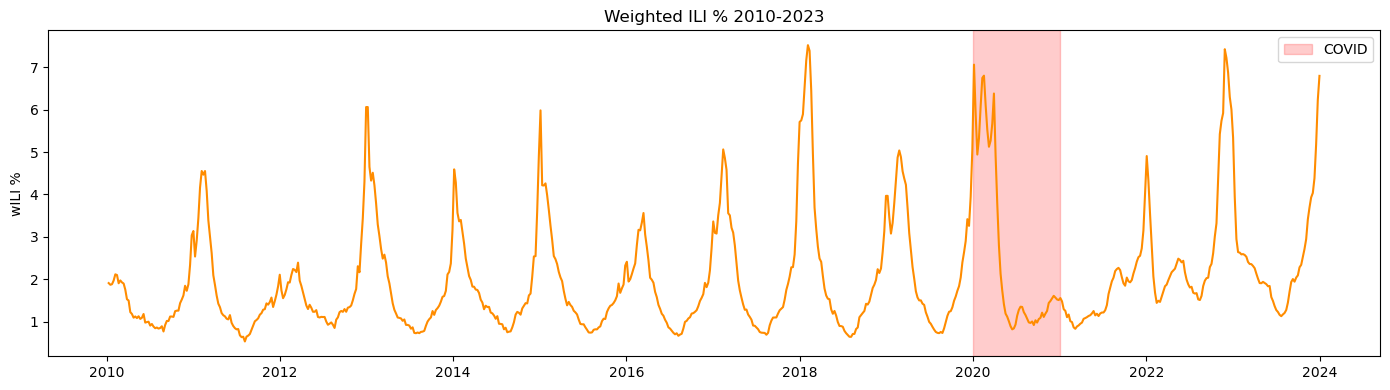

In [7]:
plt.figure(figsize=(14, 4))
plt.plot(master_df.index, master_df['wili'], color='darkorange')
plt.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
plt.title('Weighted ILI % 2010-2023')
plt.ylabel('wILI %')
plt.legend()
plt.tight_layout()
plt.savefig('plot3_ili.png', dpi=150)
plt.show()

What it shows: The CDC's weekly measure of what percentage of doctor visits were flu-like illness, over 14 years.
Interpretation: Clear seasonal pattern â€” flu spikes every winter and drops every summer, like clockwork. Interestingly, COVID disrupted the seasonal pattern in 2020-2021 â€” ILI actually dropped during early COVID because people stopped going to the doctor. Then it rebounded.
Relevance: This is your core health surveillance signal. The seasonal pattern is strong and consistent but the market doesn't react to it â€” routine flu seasons don't move stocks. That's a key finding. The market only reacted when something broke the pattern.

### Health Signal: Google Trends — Flu Symptoms

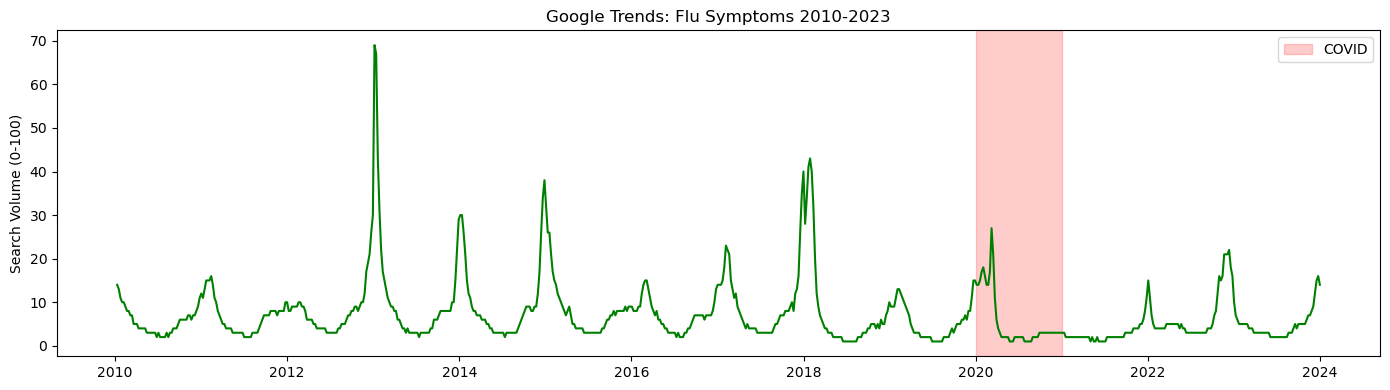

In [8]:
plt.figure(figsize=(14, 4))
plt.plot(master_df.index, master_df['trends_flu_symptoms'], color='green')
plt.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
plt.title('Google Trends: Flu Symptoms 2010-2023')
plt.ylabel('Search Volume (0-100)')
plt.legend()
plt.tight_layout()
plt.savefig('plot4_trends.png', dpi=150)
plt.show()

What it shows: How often Americans searched "flu symptoms" on Google each week.
Interpretation: Also seasonal, also spikes in winter. But the pattern is noisier than FluView and the COVID period shows a massive spike in early 2020 that doesn't match the normal seasonal pattern â€” people were searching symptoms they'd never had before.
Relevance: Google Trends is a leading indicator â€” people search before they go to the doctor. If search volume spikes before ILI spikes, that's the pre-announcement signal your project is looking for. The COVID spike happened before official announcements, which is the core hypothesis being tested.

### Overlay: Market Volatility vs ILI

A dual-axis chart placing the target variable (ETF volatility) and the primary health signal (wILI) on the same timeline, making alignment or misalignment during different periods immediately visible.

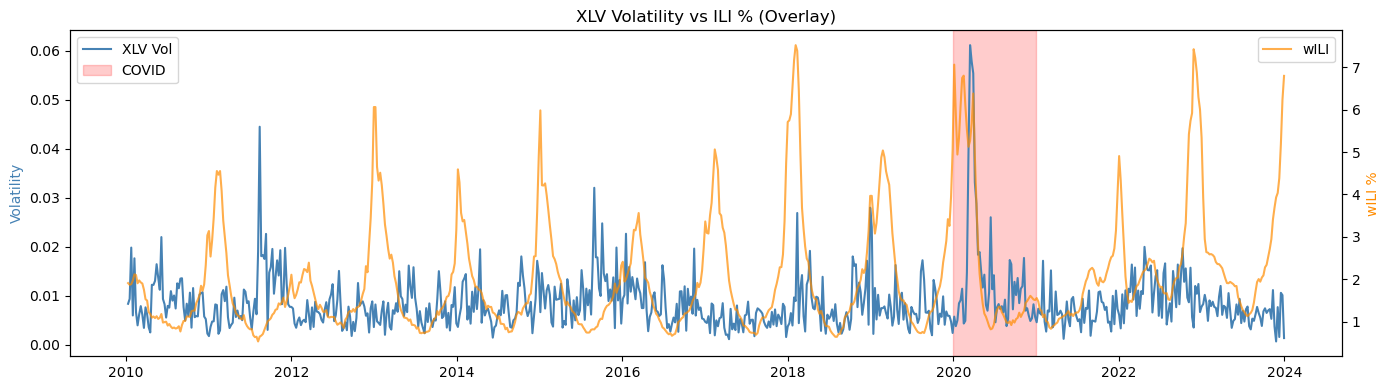

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
ax2 = ax.twinx()
ax.plot(master_df.index, master_df['XLV_vol'], color='steelblue', label='XLV Vol')
ax2.plot(master_df.index, master_df['wili'], color='darkorange', alpha=0.7, label='wILI')
ax.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
ax.set_title('XLV Volatility vs ILI % (Overlay)')
ax.set_ylabel('Volatility', color='steelblue')
ax2.set_ylabel('wILI %', color='darkorange')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('plot5_overlay.png', dpi=150)
plt.show()

What it shows: XLV volatility (blue, left axis) and weighted ILI (orange, right axis) on the same chart with two y-axes.
Interpretation: In normal flu seasons, ILI spikes every winter but XLV volatility barely moves. During COVID, both spike simultaneously but the volatility spike is far more dramatic and happens faster. The two lines don't track each other consistently â€” they only converge during extreme events.
Relevance: This is the visual proof of your core finding. The relationship between health signals and volatility is not consistent â€” it's conditional on the severity of the health event. This justifies your research question and motivates the predictive model.

## Correlation Analysis

Quantifies the linear relationship between health signals and sector volatility across the full dataset and across subgroups. Pearson correlations are used throughout; because volatility is not normally distributed (confirmed below), these values should be interpreted as directional indicators rather than precise effect sizes.

### Full Period: Health Signals vs Sector Volatility

Correlates each of the four health signals against each of the four ETF volatility columns using the complete 2010-2023 dataset.

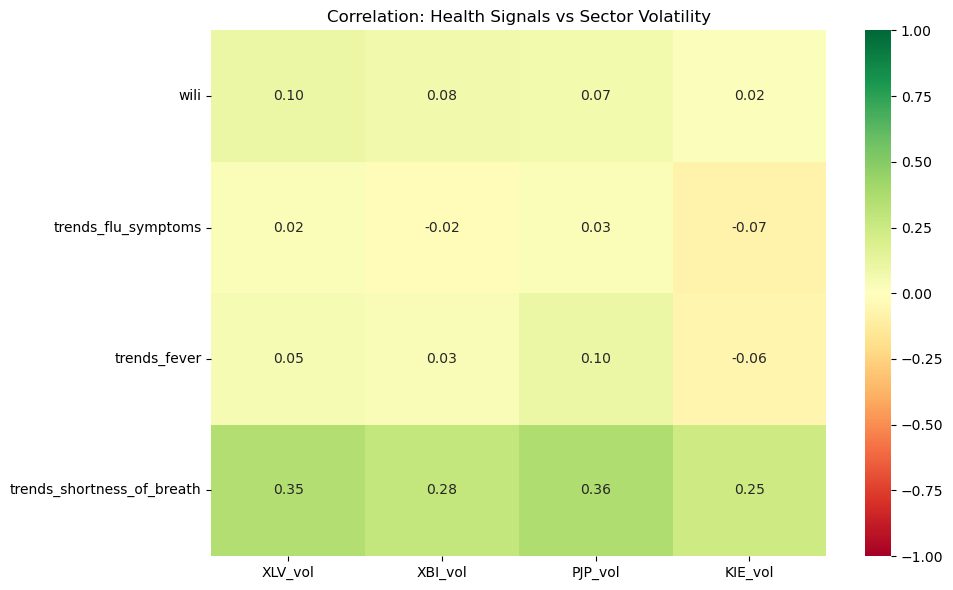

In [10]:
import seaborn as sns

# Correlate health signals against each ETF volatility
health_signals = ['wili', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath']
vol_cols = ['XLV_vol', 'XBI_vol', 'PJP_vol', 'KIE_vol']

corr_matrix = master_df[health_signals + vol_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix.loc[health_signals, vol_cols], 
            annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1)
plt.title('Correlation: Health Signals vs Sector Volatility')
plt.tight_layout()
plt.savefig('plot6_correlation.png', dpi=150)
plt.show()

`trends_shortness_of_breath` shows the strongest correlation with all four volatility measures, driven largely by the COVID period. `wili` and `trends_flu_symptoms` show weaker but consistent positive correlations. The pre-COVID subset below isolates the baseline relationship outside the COVID shock.

### Pre-COVID Only (2010-2019)

Repeats the correlation analysis on data before January 2020 to test whether any health-market relationship exists outside the pandemic shock.

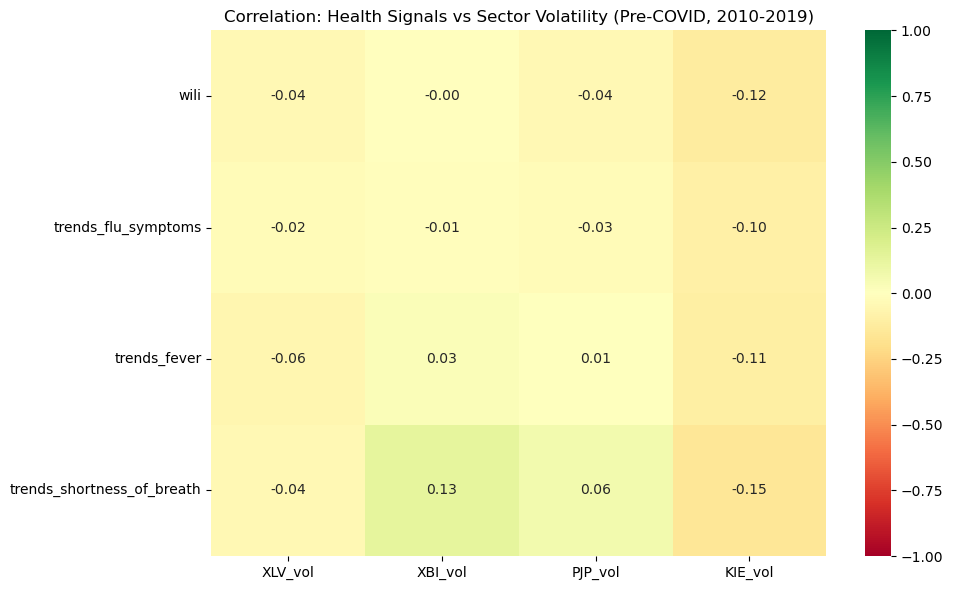

In [11]:
pre_covid = master_df[master_df.index < '2020-01-01']

corr_pre = pre_covid[health_signals + vol_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_pre.loc[health_signals, vol_cols],
            annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1)
plt.title('Correlation: Health Signals vs Sector Volatility (Pre-COVID, 2010-2019)')
plt.tight_layout()
plt.savefig('plot7_correlation_precovid.png', dpi=150)
plt.show()

Pre-COVID correlations are near zero or slightly negative, confirming that routine flu seasons do not meaningfully move health-sector volatility. The full-period correlations are almost entirely driven by the COVID event.

## Statistical Assumption Tests

Before modeling, three key assumptions are tested: normality of the target variable, multicollinearity among health signals, and independence of observations (autocorrelation). Results from these tests directly inform modeling decisions in Phase 2.

### Normality — Shapiro-Wilk Test

Tests whether each ETF weekly volatility series follows a normal distribution. The null hypothesis is normality; p < 0.05 rejects it.

In [12]:
# Normality - Shapiro-Wilk test on volatility columns
from scipy import stats

for col in ['XLV_vol', 'XBI_vol', 'PJP_vol', 'KIE_vol']:
    stat, p = stats.shapiro(master_df[col])
    print(f"{col}: p={p:.4f} â€” {'NOT normal' if p < 0.05 else 'normal'}")

XLV_vol: p=0.0000 â€” NOT normal
XBI_vol: p=0.0000 â€” NOT normal
PJP_vol: p=0.0000 â€” NOT normal
KIE_vol: p=0.0000 â€” NOT normal


All four volatility series strongly reject normality (p = 0.0000). This is expected for financial volatility, which is right-skewed with heavy tails. Non-parametric methods or log-transformed targets should be considered in modeling.

### Multicollinearity — Health Signal Intercorrelations

Checks pairwise correlations among the four health predictors. High inter-predictor correlations can destabilize regression coefficients even when individual correlations with the target are meaningful.

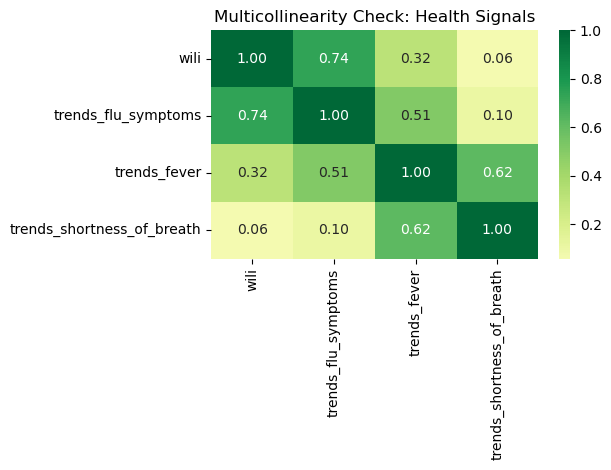

In [13]:
# Multicollinearity - correlation among health signals only
health_corr = master_df[['wili', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath']].corr()
sns.heatmap(health_corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Multicollinearity Check: Health Signals')
plt.tight_layout()
plt.savefig('plot8_multicollinearity.png', dpi=150)
plt.show()

`trends_fever` and `trends_shortness_of_breath` correlate at roughly 0.62, and both correlate with `wili` at moderate levels. `trends_shortness_of_breath` is the most distinct signal. Consider dropping or combining highly correlated predictors before fitting a linear model.

### Autocorrelation — Durbin-Watson Test

Tests for serial correlation in the volatility series. Values near 2 indicate independence; values near 0 indicate strong positive autocorrelation.

In [14]:
# Independence - Durbin-Watson test on XLV volatility
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(master_df['XLV_vol'])
print(f"Durbin-Watson: {dw:.4f}")
print("Close to 2 = independent, <2 = positive autocorrelation, >2 = negative")

Durbin-Watson: 0.2758
Close to 2 = independent, <2 = positive autocorrelation, >2 = negative


A Durbin-Watson statistic of 0.2758 indicates strong positive autocorrelation — this week's volatility is strongly predicted by last week's volatility. Any model must account for this temporal dependence, e.g. by including lagged volatility as a feature or using time-series-aware cross-validation.

## Subgroup Correlation Analysis

Beyond the full-period and pre-COVID splits, two additional subgroups test whether the health-market relationship is seasonal or era-specific.

### Flu Season Only (September-December)

Filters to the four months when influenza is most active. If health signals drive volatility even in non-pandemic years, flu-season correlations should be higher than the full-period baseline.

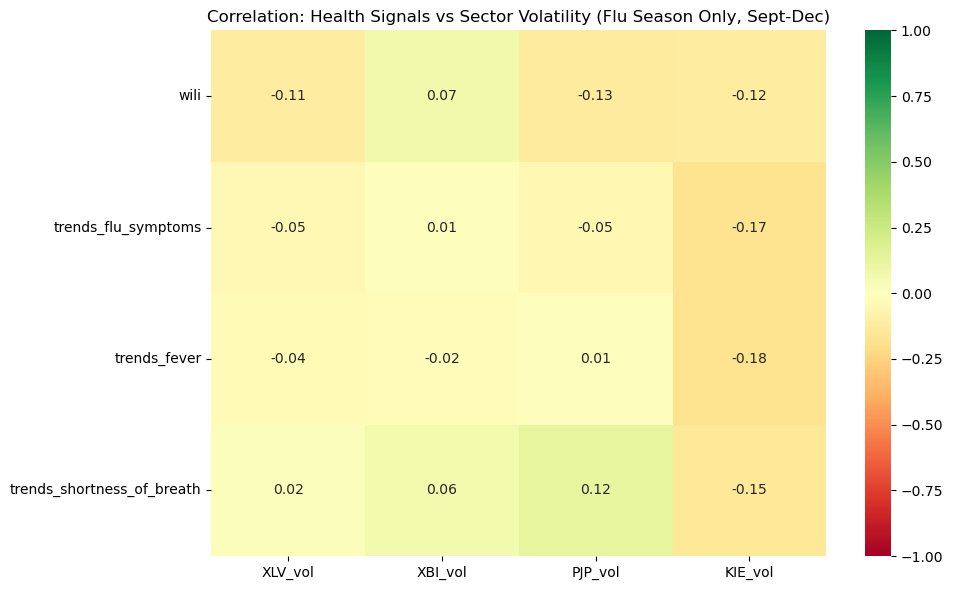

Rows in flu season subset: 244


In [15]:
# Filter to flu season months only (September through December)
flu_season = master_df[master_df.index.month.isin([9, 10, 11, 12])]

health_signals = ['wili', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath']
vol_cols = ['XLV_vol', 'XBI_vol', 'PJP_vol', 'KIE_vol']

corr_flu_season = flu_season[health_signals + vol_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_flu_season.loc[health_signals, vol_cols],
            annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1)
plt.title('Correlation: Health Signals vs Sector Volatility (Flu Season Only, Sept-Dec)')
plt.tight_layout()
plt.savefig('plot8_correlation_fluseason.png', dpi=150)
plt.show()

print(f"Rows in flu season subset: {len(flu_season)}")

Flu-season correlations are not materially higher than the full-period values, reinforcing the finding that seasonal flu alone does not trigger healthcare-sector market volatility — scale and novelty of the health event matter more than seasonality.

### Period Comparison: Pre-COVID / COVID / Post-COVID

Splits the data into three eras and computes a separate correlation heatmap for each, revealing whether the health-market relationship is stable, emergent, or transient.

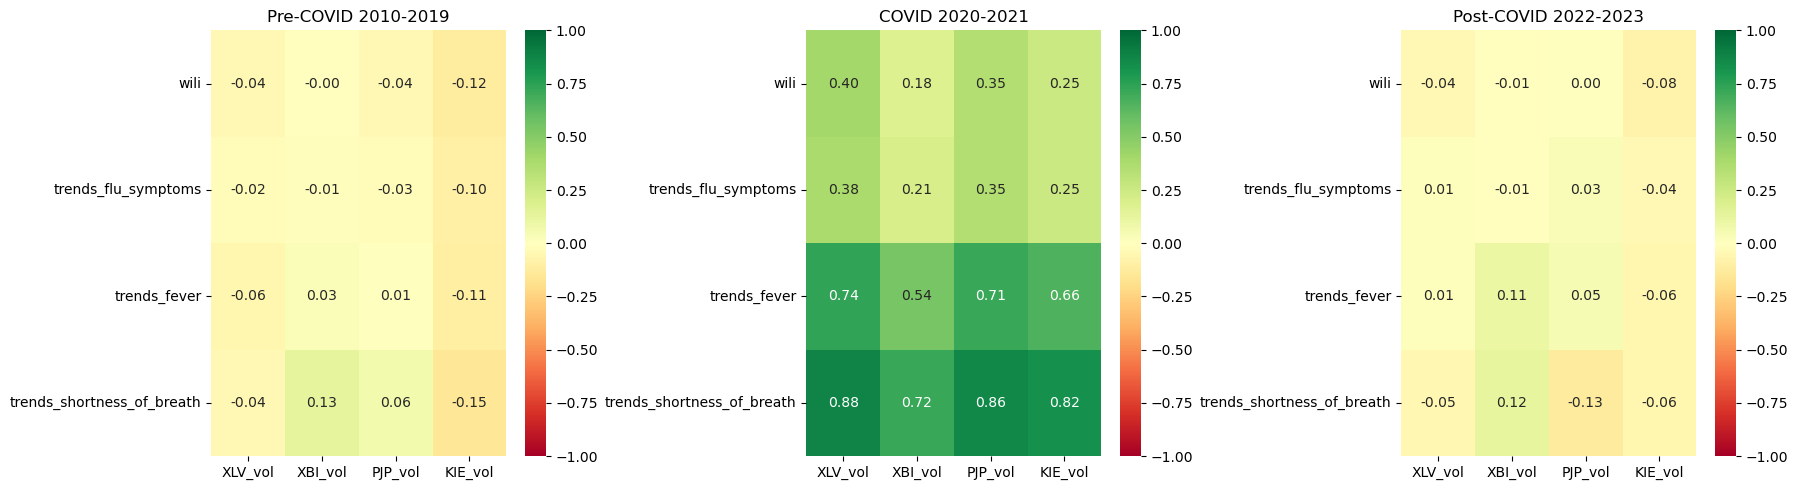

In [16]:
# Three period windows
pre_covid = master_df[master_df.index < '2020-01-01']
covid = master_df[(master_df.index >= '2020-01-01') & (master_df.index < '2022-01-01')]
post_covid = master_df[master_df.index >= '2022-01-01']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
periods = [('Pre-COVID 2010-2019', pre_covid), 
           ('COVID 2020-2021', covid), 
           ('Post-COVID 2022-2023', post_covid)]

for ax, (title, df) in zip(axes, periods):
    corr = df[health_signals + vol_cols].corr().loc[health_signals, vol_cols]
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('plot9_three_periods.png', dpi=150)
plt.show()

Correlations shift dramatically across eras. The COVID window (2020-2021) shows strong positive correlations. Pre-COVID and post-COVID correlations revert toward zero, suggesting the relationship is crisis-specific rather than a persistent structural link.

## Full Feature Correlation Matrix

Shows pairwise correlations across all 19 features to surface multicollinearity, redundant variables, and spurious time-trend correlations before feature selection.

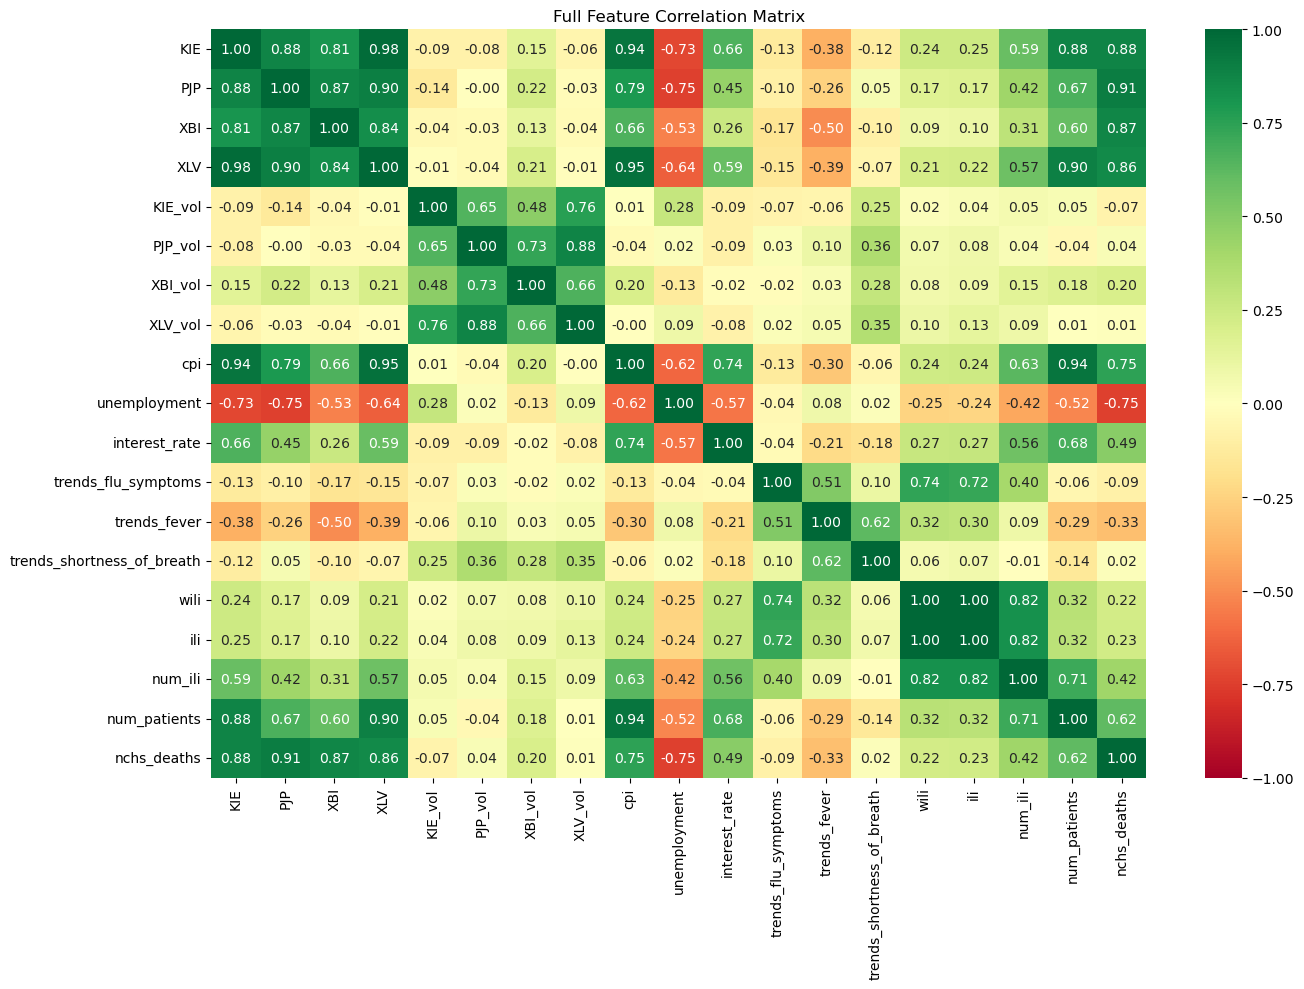

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
sns.heatmap(master_df.corr(), annot=True, fmt='.2f', 
            cmap='RdYlGn', center=0, vmin=-1, vmax=1)
plt.title('Full Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('plot10_full_correlation.png', dpi=150)
plt.show()

Massive multicollinearity in the price columns:
KIE, PJP, XBI, XLV are all correlated with each other at 0.81-0.98. They move together. You don't need all four closing prices â€” they're basically the same signal. Drop the closing prices entirely from the model, keep only the volatility columns since those are your target variables.
wili and ili are 1.00 correlated. They're identical. Drop ili, keep wili.
num_patients is 0.94 correlated with CPI. That's a spurious correlation â€” both trend upward over time. num_patients adds nothing beyond what CPI already captures.
NCHS deaths correlates 0.88 with KIE and 0.91 with PJP. That's not a real relationship â€” it's because both trend upward over time. Confirms your instinct to drop it.
trends_fever and trends_shortness_of_breath correlate at 0.62. Moderate â€” you can keep both for now but watch this in modeling.
Here's what to keep for modeling:
Target variables: XLV_vol, XBI_vol, PJP_vol, KIE_vol
Features: cpi, unemployment, interest_rate, trends_flu_symptoms, trends_fever, trends_shortness_of_breath, wili, num_ili
Drop: KIE, PJP, XBI, XLV (closing prices), ili (duplicate of wili), num_patients (redundant), nchs_deaths (constant/spurious)

## Lag Analysis

Tests whether health signals from 1-4 weeks prior are better predictors of current volatility than contemporaneous signals. A leading indicator relationship would be essential for any forward-looking model.

In [18]:
# Test whether health signals from prior weeks predict this week's volatility
# Lag 1 = last week, Lag 2 = 2 weeks ago, etc.

lag_results = []

for signal in ['wili', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath']:
    for lag in range(1, 5):
        lagged = master_df[signal].shift(lag)
        corr = lagged.corr(master_df['XLV_vol'])
        lag_results.append({'signal': signal, 'lag_weeks': lag, 'correlation': round(corr, 3)})

lag_df = pd.DataFrame(lag_results)
print(lag_df.to_string(index=False))

                    signal  lag_weeks  correlation
                      wili          1        0.112
                      wili          2        0.124
                      wili          3        0.140
                      wili          4        0.162
       trends_flu_symptoms          1        0.046
       trends_flu_symptoms          2        0.067
       trends_flu_symptoms          3        0.068
       trends_flu_symptoms          4        0.066
              trends_fever          1        0.042
              trends_fever          2        0.026
              trends_fever          3       -0.003
              trends_fever          4       -0.012
trends_shortness_of_breath          1        0.302
trends_shortness_of_breath          2        0.232
trends_shortness_of_breath          3        0.144
trends_shortness_of_breath          4        0.072


`trends_shortness_of_breath` at lag 1 (r = 0.302) is the strongest predictor found in the dataset — stronger than any contemporaneous correlation. `wili` shows a modest but increasing pattern with longer lags. `trends_fever` loses predictive value beyond lag 1. These results suggest that search behavior around respiratory distress precedes market volatility by approximately one week.

## Rolling Correlation

Computes a 52-week rolling Pearson correlation between `wili` and `XLV_vol`. A time-varying correlation reveals when the health-market relationship is active versus dormant, and whether it persists after the COVID shock.

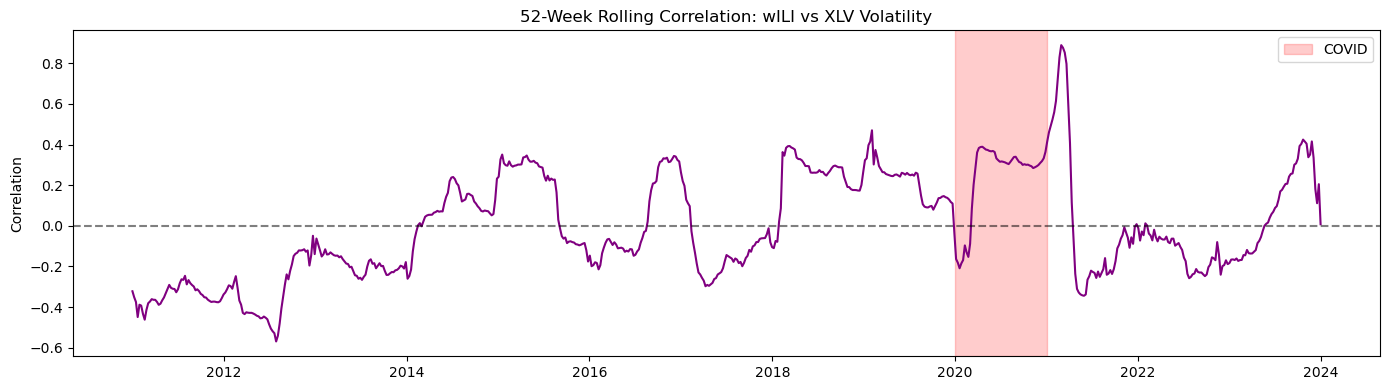

In [19]:
# 52-week rolling correlation between wILI and XLV_vol
# Shows when the relationship turns on and off over time

rolling_corr = master_df['wili'].rolling(52).corr(master_df['XLV_vol'])

plt.figure(figsize=(14, 4))
plt.plot(master_df.index, rolling_corr, color='purple')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
plt.title('52-Week Rolling Correlation: wILI vs XLV Volatility')
plt.ylabel('Correlation')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot11_rolling_correlation.png', dpi=150)
plt.show()

The rolling correlation hovers near zero for most of the pre-COVID decade, spikes sharply during the 2020 COVID onset, then gradually decays back toward baseline. This confirms the health-market relationship is regime-dependent: it activates during genuine health crises and is otherwise absent.

## Volatility Spike Detection

Defines a volatility spike as any week where XLV volatility exceeds 1.5 times its historical mean, then identifies and visualizes all spike weeks.

Mean XLV volatility: 0.0085
Spike threshold (1.5x mean): 0.0128
Total weeks: 730
Spike weeks: 109
Spike rate: 14.9%


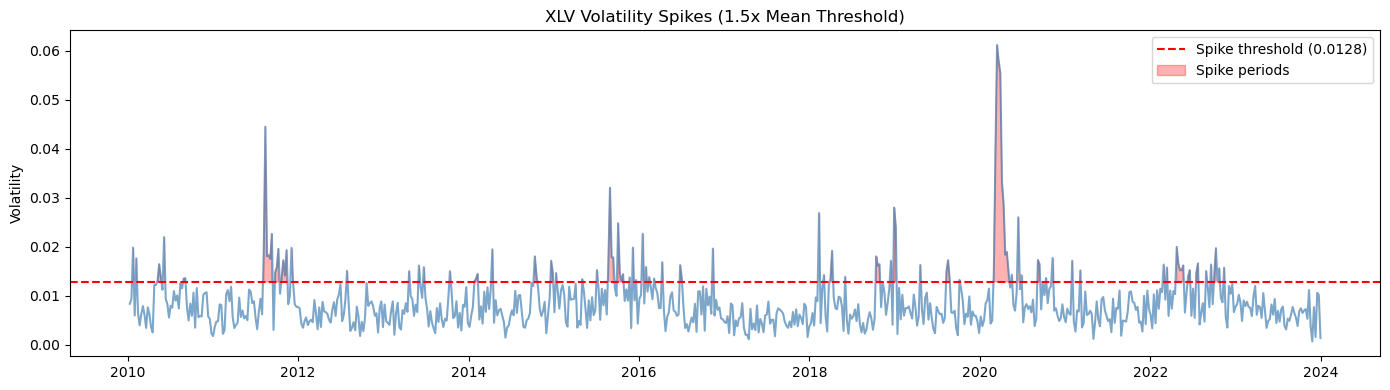

In [20]:
# Define a volatility spike as XLV_vol exceeding 1.5x its historical mean
threshold = master_df['XLV_vol'].mean() * 1.5
spikes = (master_df['XLV_vol'] > threshold).astype(int)

print(f"Mean XLV volatility: {master_df['XLV_vol'].mean():.4f}")
print(f"Spike threshold (1.5x mean): {threshold:.4f}")
print(f"Total weeks: {len(master_df)}")
print(f"Spike weeks: {spikes.sum()}")
print(f"Spike rate: {spikes.mean()*100:.1f}%")

plt.figure(figsize=(14, 4))
plt.plot(master_df.index, master_df['XLV_vol'], color='steelblue', alpha=0.7)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Spike threshold ({threshold:.4f})')
plt.fill_between(master_df.index, threshold, master_df['XLV_vol'],
                 where=master_df['XLV_vol'] > threshold,
                 color='red', alpha=0.3, label='Spike periods')
plt.title('XLV Volatility Spikes (1.5x Mean Threshold)')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot12_volatility_spikes.png', dpi=150)
plt.show()

Spike weeks are concentrated almost entirely in the COVID period. The 1.5x mean threshold cleanly separates COVID-era market stress from normal fluctuation, validating it as a reasonable binary classification target for a predictive model.